In [59]:
# python
import os
import pyarrow.parquet as pq
import pandas as pd

path = '../data/yellow_tripdata_2025-01.parquet'
if not os.path.exists(path):
    raise FileNotFoundError(path)

try:
    # prefer disabling pandas metadata to avoid extension registration errors
    table = pq.read_table(path, use_pandas_metadata=False)
except TypeError:
    # older pyarrow may not accept the arg
    table = pq.read_table(path)

data = table.to_pandas()
data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


Ile jest rekordów?

In [60]:
len(data)

3475226

Ile jest zmiennych numerycznych?

In [61]:
numeryczne = data.select_dtypes(include='number')
len(numeryczne.columns)

17

Ile jest zmiennych kategorycznych?

In [70]:
kategoryczne = data.select_dtypes(include=['str'])
len(kategoryczne.columns)

1

Czy istnieją jeszcze inne typy danych?

In [71]:
data.dtypes

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

W których kolumnach występują braki danych?

In [72]:
data.isna().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          540149
trip_distance                 0
RatecodeID               540149
store_and_fwd_flag       540149
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     540149
Airport_fee              540149
cbd_congestion_fee            0
dtype: int64

Czy braki danych współwystępują w tych samych wierszach?

In [65]:
(data.isna().sum(axis=1) > 1).sum()

np.int64(540149)

Czy braki danych są losowe czy systematyczne?

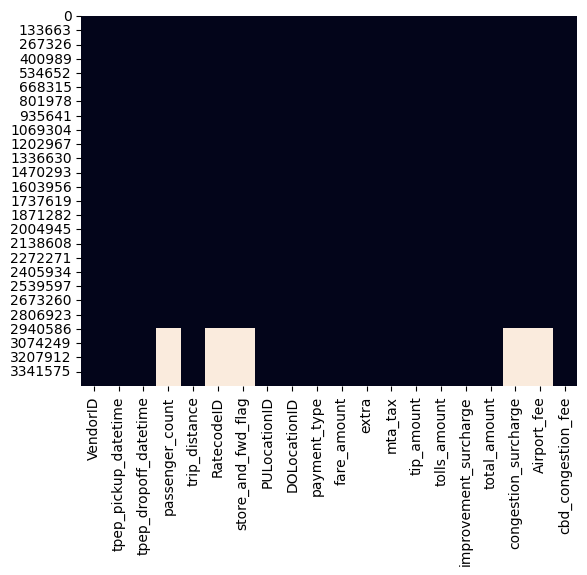

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(data.isna(), cbar=False)
plt.show()

Jak wygląda rozkład przebytego dystansu?


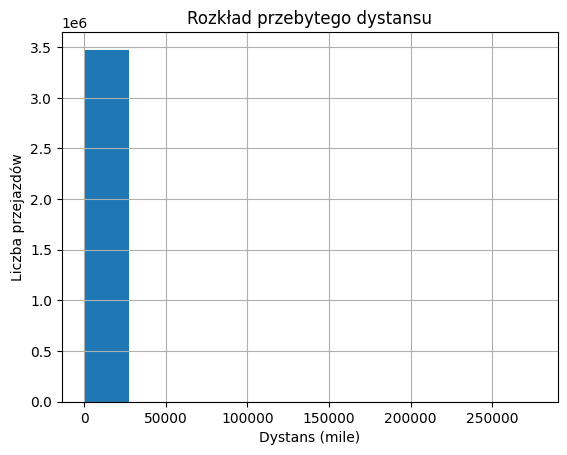

In [67]:
data['trip_distance'].hist(bins=10)
plt.title("Rozkład przebytego dystansu")
plt.xlabel("Dystans (mile)")
plt.ylabel("Liczba przejazdów")
plt.show()

Jak wygląda rozkład opłaty?


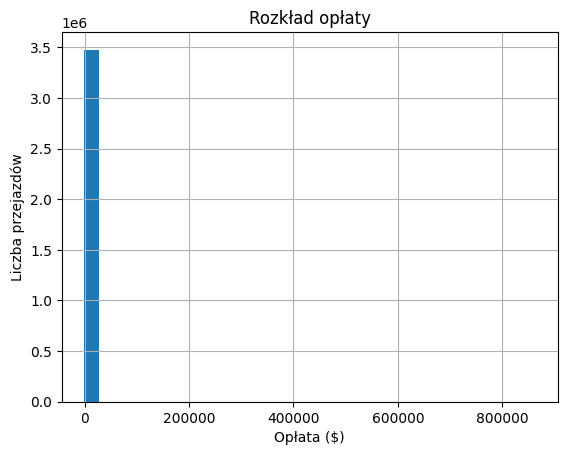

In [68]:
data['fare_amount'].hist(bins=30)
plt.title("Rozkład opłaty")
plt.xlabel("Opłata ($)")
plt.ylabel("Liczba przejazdów")
plt.show()

Jak wygląda rozkład liczby pasażerów?

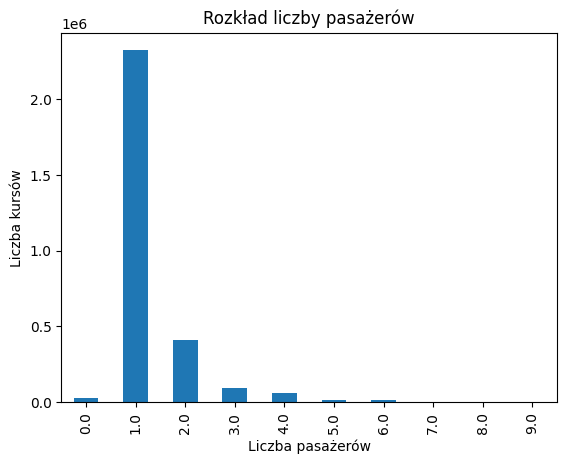

In [73]:
data['passenger_count'].value_counts().sort_index().plot(kind='bar')
plt.title("Rozkład liczby pasażerów")
plt.xlabel("Liczba pasażerów")
plt.ylabel("Liczba kursów")
plt.show()